In [2]:
# Cell 1 — setup + GPU gate
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import load_img, img_to_array

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

PROJECT_ROOT = Path("/teamspace/studios/this_studio/accessops_coco_ai")
CSV_PATH = PROJECT_ROOT / "artifacts" / "captions_clean_with_splits.csv"
PREPROC_CFG_PATH = PROJECT_ROOT / "artifacts" / "stage1c_preprocess" / "preprocess_config.json"
TOKENIZER_PATH = PROJECT_ROOT / "artifacts" / "stage1c_preprocess" / "tokenizer.json"

ART_DIR = PROJECT_ROOT / "artifacts" / "stage3"
MODEL_DIR = PROJECT_ROOT / "models" / "stage3_scratch_cnn_lstm"
ART_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

gpus = tf.config.list_physical_devices("GPU")
print("TF:", tf.__version__)
print("GPUs:", gpus)
assert len(gpus) > 0, "No GPU detected."

for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)

assert CSV_PATH.exists(), f"Missing: {CSV_PATH}"
assert PREPROC_CFG_PATH.exists(), f"Missing: {PREPROC_CFG_PATH}"
assert TOKENIZER_PATH.exists(), f"Missing: {TOKENIZER_PATH}"


2026-04-07 05:03:28.493699: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-07 05:03:28.513571: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-07 05:03:28.542364: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-07 05:03:28.542424: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-07 05:03:28.560050: I tensorflow/core/platform/cpu_feature_gua

TF: 2.16.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Cell 2 — load preprocessing config + tokenizer
pre_cfg = json.loads(PREPROC_CFG_PATH.read_text(encoding="utf-8"))
MAX_LEN = int(pre_cfg["sequence"]["max_length"])
VOCAB_SIZE = int(pre_cfg["vocab"]["selected_vocab_size"])
SEQ_LEN = MAX_LEN - 1

tokenizer = tokenizer_from_json(TOKENIZER_PATH.read_text(encoding="utf-8"))
if tokenizer.num_words is None:
    tokenizer.num_words = VOCAB_SIZE

start_id = tokenizer.word_index.get("<start>")
end_id = tokenizer.word_index.get("<end>")
assert start_id is not None and end_id is not None, "Missing <start>/<end> in tokenizer"

print("MAX_LEN:", MAX_LEN, "SEQ_LEN:", SEQ_LEN, "VOCAB_SIZE:", VOCAB_SIZE)
print("Tokenizer vocab observed:", len(tokenizer.word_index))
print("start_id:", start_id, "end_id:", end_id)


MAX_LEN: 30 SEQ_LEN: 29 VOCAB_SIZE: 30000
Tokenizer vocab observed: 29078
start_id: 3 end_id: 4


In [4]:
# Cell 3 — load COCO rows + rebuild valid image paths
df = pd.read_csv(CSV_PATH)
df["comment_clean"] = df["comment_clean"].astype(str).str.strip().str.lower()
df["split"] = df["split"].astype(str).str.strip().str.lower()
df["image_name"] = df["image_name"].astype(str).str.strip()
df = df[df["comment_clean"].str.len() > 0].reset_index(drop=True)

train_candidates = [
    PROJECT_ROOT / "data" / "coco" / "train2017",
    PROJECT_ROOT / "artifacts" / "data" / "coco" / "train2017",
    PROJECT_ROOT / "data" / "coco" / "raw" / "train2017",
]
val_candidates = [
    PROJECT_ROOT / "data" / "coco" / "val2017",
    PROJECT_ROOT / "artifacts" / "data" / "coco" / "val2017",
    PROJECT_ROOT / "data" / "coco" / "raw" / "val2017",
]

TRAIN_IMG_DIR = next((p for p in train_candidates if p.exists()), train_candidates[0])
VAL_IMG_DIR = next((p for p in val_candidates if p.exists()), val_candidates[0])

print("TRAIN_IMG_DIR:", TRAIN_IMG_DIR, TRAIN_IMG_DIR.exists())
print("VAL_IMG_DIR:", VAL_IMG_DIR, VAL_IMG_DIR.exists())

df["image_path"] = np.where(
    df["split"].eq("train"),
    df["image_name"].map(lambda n: str(TRAIN_IMG_DIR / n)),
    df["image_name"].map(lambda n: str(VAL_IMG_DIR / n))  # val + test from val2017
)

exists = df["image_path"].map(lambda p: Path(p).exists())
df = df[exists].reset_index(drop=True)

# reference captions for BLEU (all refs per image)
references_by_image = df.groupby("image_name")["comment_clean"].apply(list).to_dict()

print("Rows by split:")
print(df["split"].value_counts())
print("Unique images by split:")
print(df.groupby("split")["image_name"].nunique())


TRAIN_IMG_DIR: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/data/coco/train2017 True
VAL_IMG_DIR: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/data/coco/val2017 True
Rows by split:
split
train    591753
val       12508
test      12506
Name: count, dtype: int64
Unique images by split:
split
test       2500
train    118287
val        2500
Name: image_name, dtype: int64


In [5]:
# Cell 4 — build decoder inputs/targets from full caption rows
def wrap_caption(c: str) -> str:
    return f"<start> {c} <end>"

df["caption_wrapped"] = df["comment_clean"].map(wrap_caption)

def make_split(split_name: str):
    part = df[df["split"] == split_name].reset_index(drop=True)
    names = part["image_name"].astype(str).to_numpy()
    paths = part["image_path"].astype(str).to_numpy()

    seq = tokenizer.texts_to_sequences(part["caption_wrapped"].tolist())
    seq = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post").astype(np.int32)

    dec_in = seq[:, :-1]   # [N, SEQ_LEN]
    y_out = seq[:, 1:]     # [N, SEQ_LEN]
    return names, paths, dec_in, y_out

train_names, train_paths, train_dec_in, train_y = make_split("train")
val_names, val_paths, val_dec_in, val_y = make_split("val")
test_names, test_paths, test_dec_in, test_y = make_split("test")

split_sizes = {
    "train_caption_rows": int(len(train_names)),
    "val_caption_rows": int(len(val_names)),
    "test_caption_rows": int(len(test_names)),
    "train_unique_images": int(pd.Series(train_names).nunique()),
    "val_unique_images": int(pd.Series(val_names).nunique()),
    "test_unique_images": int(pd.Series(test_names).nunique()),
    "max_len": int(MAX_LEN),
    "seq_len": int(SEQ_LEN),
    "vocab_size": int(VOCAB_SIZE),
}
(ART_DIR / "selected_split_sizes.json").write_text(json.dumps(split_sizes, indent=2), encoding="utf-8")
print(json.dumps(split_sizes, indent=2))


{
  "train_caption_rows": 591753,
  "val_caption_rows": 12508,
  "test_caption_rows": 12506,
  "train_unique_images": 118287,
  "val_unique_images": 2500,
  "test_unique_images": 2500,
  "max_len": 30,
  "seq_len": 29,
  "vocab_size": 30000
}


In [6]:
# Cell 5 — tf.data
IMG_SIZE = 192
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def load_example(path, dec_in, y):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return {"image_input": img, "text_input": dec_in}, y

def augment(inputs, y):
    img = inputs["image_input"]
    txt = inputs["text_input"]
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.04)
    img = tf.image.random_contrast(img, 0.95, 1.05)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return {"image_input": img, "text_input": txt}, y

def make_ds(paths, dec_in, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, dec_in, y))
    ds = ds.map(lambda p, d, t: load_example(p, tf.cast(d, tf.int32), tf.cast(t, tf.int32)),
                num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(min(len(paths), 50000), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_paths, train_dec_in, train_y, training=True)
val_ds = make_ds(val_paths, val_dec_in, val_y, training=False)
test_ds = make_ds(test_paths, test_dec_in, test_y, training=False)

print("Datasets ready.")


2026-04-07 05:04:05.696525: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79187 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:00:05.0, compute capability: 8.0


Datasets ready.


In [7]:
# Cell 6 — scratch CNN + LSTM model
tf.keras.backend.clear_session()

image_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")

x = layers.Conv2D(32, 3, padding="same", use_bias=False)(image_input)
x = layers.BatchNormalization()(x); x = layers.ReLU()(x); x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x); x = layers.ReLU()(x); x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128, 3, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x); x = layers.ReLU()(x); x = layers.MaxPooling2D()(x)

x = layers.Conv2D(256, 3, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x); x = layers.ReLU()(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.30)(x)
img_feat = layers.Dense(384, activation="relu")(x)

text_input = layers.Input(shape=(SEQ_LEN,), dtype="int32", name="text_input")
emb = layers.Embedding(input_dim=VOCAB_SIZE, output_dim=384, mask_zero=False)(text_input)
dec = layers.LSTM(512, return_sequences=True, dropout=0.30)(emb)

img_rep = layers.Lambda(lambda t: tf.tile(tf.expand_dims(t, axis=1), [1, SEQ_LEN, 1]))(img_feat)
merged = layers.Concatenate(axis=-1)([dec, img_rep])

h = layers.TimeDistributed(layers.Dense(512, activation="relu"))(merged)
h = layers.Dropout(0.30)(h)
out = layers.TimeDistributed(layers.Dense(VOCAB_SIZE, activation="softmax", dtype="float32"))(h)

model = models.Model(inputs=[image_input, text_input], outputs=out)

scce = tf.keras.losses.SparseCategoricalCrossentropy(reduction="none")

def masked_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    loss = scce(y_true, y_pred)   # [B, T]
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    return tf.reduce_sum(loss * mask) / (tf.reduce_sum(mask) + 1e-8)

def masked_accuracy(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    pred_ids = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
    match = tf.cast(tf.equal(y_true, pred_ids), tf.float32)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    return tf.reduce_sum(match * mask) / (tf.reduce_sum(mask) + 1e-8)

model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss=masked_loss,
    metrics=[masked_accuracy],
    jit_compile=False,
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 192, 192,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 192, 192,  │        864 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 192, 192,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 192, 192,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 96, 96,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 96, 96,    │     18,432 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 96, 96,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 48, 48,    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 48, 48,    │     73,728 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 24, 24,    │          0 │ re_lu_2[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 24, 24,    │    294,912 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 24, 24,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ re_lu_3[0][0]   

 Total params: 29,924,752 (114.15 MB)

 Trainable params: 29,923,792 (114.15 MB)

 Non-trainable params: 960 (3.75 KB)

In [8]:
# Cell 7 — train
ckpt = MODEL_DIR / "best_stage3_scratch.keras"
cb = [
    callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    callbacks.ModelCheckpoint(filepath=str(ckpt), monitor="val_loss", save_best_only=True),
    callbacks.TerminateOnNaN(),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=18,
    callbacks=cb,
    verbose=1,
)


Epoch 1/18


2026-04-07 05:04:26.318141: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 17052 of 50000
2026-04-07 05:04:46.319041: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 49861 of 50000
2026-04-07 05:04:46.399059: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.
2026-04-07 05:04:46.616545: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


9247/9247 ━━━━━━━━━━━━━━━━━━━━ 807s 83ms/step - loss: 3.1324 - masked_accuracy: 0.4179 - val_loss: 2.9909 - val_masked_accuracy: 0.4306 - learning_rate: 0.0010
Epoch 2/18


2026-04-07 05:17:46.362456: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 18968 of 50000
2026-04-07 05:17:56.364048: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 37225 of 50000


   1/9247 ━━━━━━━━━━━━━━━━━━━━ 69:45:32 27s/step - loss: 3.6155 - masked_accuracy: 0.3815

...

9247/9247 ━━━━━━━━━━━━━━━━━━━━ 797s 83ms/step - loss: 2.2658 - masked_accuracy: 0.5066 - val_loss: 2.5397 - val_masked_accuracy: 0.4892 - learning_rate: 2.5000e-04
Epoch 18/18


2026-04-07 08:50:13.779073: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 19345 of 50000
2026-04-07 08:50:23.780232: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 37329 of 50000


   1/9247 ━━━━━━━━━━━━━━━━━━━━ 70:02:56 27s/step - loss: 2.6911 - masked_accuracy: 0.4565

2026-04-07 08:50:30.886998: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


9247/9247 ━━━━━━━━━━━━━━━━━━━━ 792s 83ms/step - loss: 2.2550 - masked_accuracy: 0.5081 - val_loss: 2.5319 - val_masked_accuracy: 0.4899 - learning_rate: 2.5000e-04


In [9]:
# Cell 8 — BLEU evaluation on full test unique images
index_word = {idx: w for w, idx in tokenizer.word_index.items() if idx < VOCAB_SIZE}
index_word[0] = "<pad>"

def load_image_for_infer(image_path):
    img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = img_to_array(img).astype("float32") / 255.0
    return np.expand_dims(arr, axis=0)

def generate_caption(image_path, max_steps=SEQ_LEN):
    img = load_image_for_infer(image_path)
    tokens = [start_id]

    for _ in range(max_steps):
        dec_in = np.zeros((1, SEQ_LEN), dtype=np.int32)
        use = tokens[:SEQ_LEN]
        dec_in[0, :len(use)] = use

        pred = model.predict({"image_input": img, "text_input": dec_in}, verbose=0)[0]
        pos = min(len(use) - 1, SEQ_LEN - 1)
        nxt = int(np.argmax(pred[pos]))

        if nxt == 0 or nxt == end_id:
            break
        tokens.append(nxt)

    words = []
    for tid in tokens[1:]:
        w = index_word.get(tid, "<unk>")
        if w not in {"<pad>", "<start>", "<end>", "<unk>"}:
            words.append(w)
    return " ".join(words).strip() if words else "a person in a scene"

test_unique = sorted(set(test_names.tolist()))
sf = SmoothingFunction().method1

bleu1_scores, bleu2_scores, bleu3_scores, bleu4_scores = [], [], [], []
sample_rows = []

for n in tqdm(test_unique, desc="Stage 3 BLEU eval"):
    pred = generate_caption(Path(val_paths[0]).parent / n if (Path(val_paths[0]).parent / n).exists() else Path(test_paths[0]).parent / n)
    pred_toks = pred.split()
    refs = [c.split() for c in references_by_image.get(n, []) if isinstance(c, str) and c.strip()]
    if refs:
        bleu1_scores.append(sentence_bleu(refs, pred_toks, weights=(1, 0, 0, 0), smoothing_function=sf))
        bleu2_scores.append(sentence_bleu(refs, pred_toks, weights=(0.5, 0.5, 0, 0), smoothing_function=sf))
        bleu3_scores.append(sentence_bleu(refs, pred_toks, weights=(1/3, 1/3, 1/3, 0), smoothing_function=sf))
        bleu4_scores.append(sentence_bleu(refs, pred_toks, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=sf))

for n in test_unique[:30]:
    img_p = Path(val_paths[0]).parent / n
    if not img_p.exists():
        img_p = Path(test_paths[0]).parent / n
    sample_rows.append({
        "image_name": n,
        "generated_caption": generate_caption(img_p),
        "reference_caption_1": references_by_image.get(n, [""])[0]
    })

bleu1 = float(np.mean(bleu1_scores)) if bleu1_scores else 0.0
bleu2 = float(np.mean(bleu2_scores)) if bleu2_scores else 0.0
bleu3 = float(np.mean(bleu3_scores)) if bleu3_scores else 0.0
bleu4 = float(np.mean(bleu4_scores)) if bleu4_scores else 0.0

print("BLEU-1:", round(bleu1, 4))
print("BLEU-2:", round(bleu2, 4))
print("BLEU-3:", round(bleu3, 4))
print("BLEU-4:", round(bleu4, 4))


Stage 3 BLEU eval:   0%|          | 0/2500 [00:00<?, ?it/s]

BLEU-1: 0.5981
BLEU-2: 0.3868
BLEU-3: 0.2459
BLEU-4: 0.1685


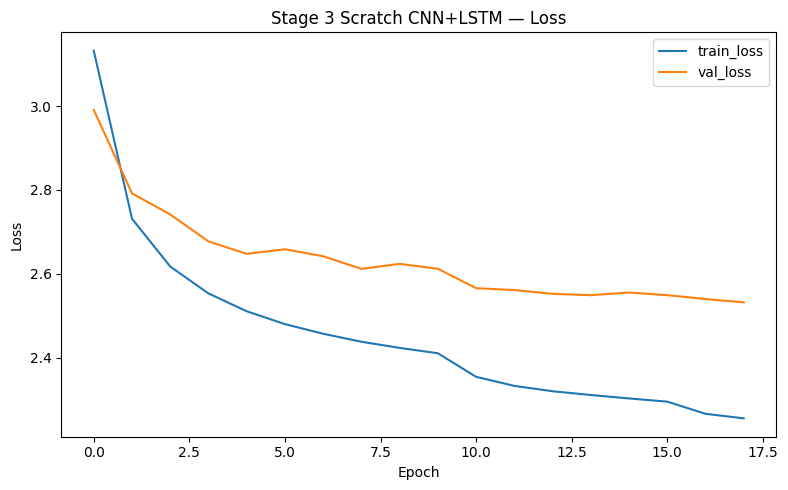

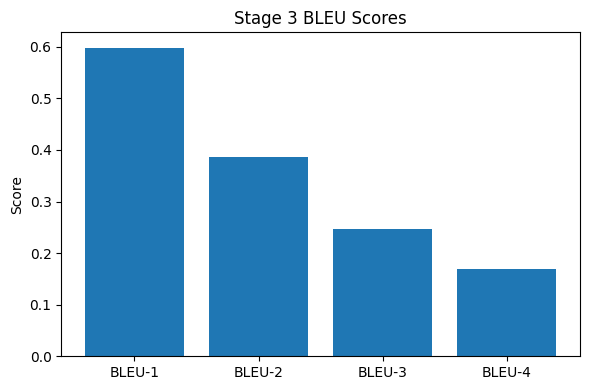

{
  "val_loss_best": 2.531853199005127,
  "val_masked_accuracy_best": 0.4899010956287384,
  "test_bleu1": 0.5981412225379819,
  "test_bleu2": 0.386823821837324,
  "test_bleu3": 0.24589569864221544,
  "test_bleu4": 0.16852079902424807,
  "eval_images_count": 2500,
  "vocab_size": 30000,
  "max_len": 30,
  "img_size": 192
}


In [10]:
# Cell 9 — save artifacts + charts + model
hist_df = pd.DataFrame(history.history)
hist_df.to_csv(ART_DIR / "training_history.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(hist_df["loss"], label="train_loss")
plt.plot(hist_df["val_loss"], label="val_loss")
plt.title("Stage 3 Scratch CNN+LSTM — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(ART_DIR / "training_curve_loss.png", dpi=180)
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"], [bleu1, bleu2, bleu3, bleu4])
plt.title("Stage 3 BLEU Scores")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig(ART_DIR / "bleu_scores.png", dpi=180)
plt.show()

pd.DataFrame(sample_rows).to_csv(ART_DIR / "sample_caption_predictions.csv", index=False)
(ART_DIR / "tokenizer.json").write_text(tokenizer.to_json(), encoding="utf-8")

metrics = {
    "val_loss_best": float(np.min(hist_df["val_loss"])),
    "val_masked_accuracy_best": float(np.max(hist_df["val_masked_accuracy"])) if "val_masked_accuracy" in hist_df.columns else None,
    "test_bleu1": bleu1,
    "test_bleu2": bleu2,
    "test_bleu3": bleu3,
    "test_bleu4": bleu4,
    "eval_images_count": int(len(test_unique)),
    "vocab_size": int(VOCAB_SIZE),
    "max_len": int(MAX_LEN),
    "img_size": int(IMG_SIZE),
}
(ART_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")

model.save(MODEL_DIR / "cnn_lstm_scratch_final.keras")
print(json.dumps(metrics, indent=2))


In [11]:
# Cell X — Stage 3 metrics table
import json, pandas as pd
from IPython.display import display

# Resolve metrics
if "metrics" in globals():
    m = metrics
else:
    m = json.loads((ART_DIR / "metrics.json").read_text(encoding="utf-8"))

metrics_table = pd.DataFrame([
    {"metric": "val_loss_best", "value": m.get("val_loss_best")},
    {"metric": "val_masked_accuracy_best", "value": m.get("val_masked_accuracy_best")},
    {"metric": "test_bleu1", "value": m.get("test_bleu1")},
    {"metric": "test_bleu2", "value": m.get("test_bleu2")},
    {"metric": "test_bleu3", "value": m.get("test_bleu3")},
    {"metric": "test_bleu4", "value": m.get("test_bleu4")},
    {"metric": "eval_images_count", "value": m.get("eval_images_count")},
    {"metric": "vocab_size", "value": m.get("vocab_size")},
    {"metric": "max_len", "value": m.get("max_len")},
    {"metric": "img_size", "value": m.get("img_size")},
])

metrics_table.to_csv(ART_DIR / "metrics_table.csv", index=False)
display(metrics_table)
print("Saved:", ART_DIR / "metrics_table.csv")


,metric,value
0,val_loss_best,2.531853
1,val_masked_accuracy_best,0.489901
2,test_bleu1,0.598141
3,test_bleu2,0.386824
4,test_bleu3,0.245896
5,test_bleu4,0.168521
6,eval_images_count,2500.000000
7,vocab_size,30000.000000
8,max_len,30.000000
9,img_size,192.000000


Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage3/metrics_table.csv


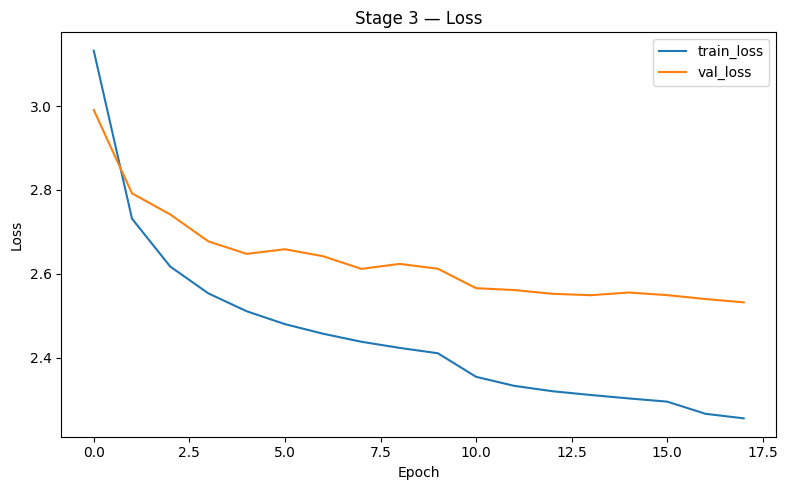

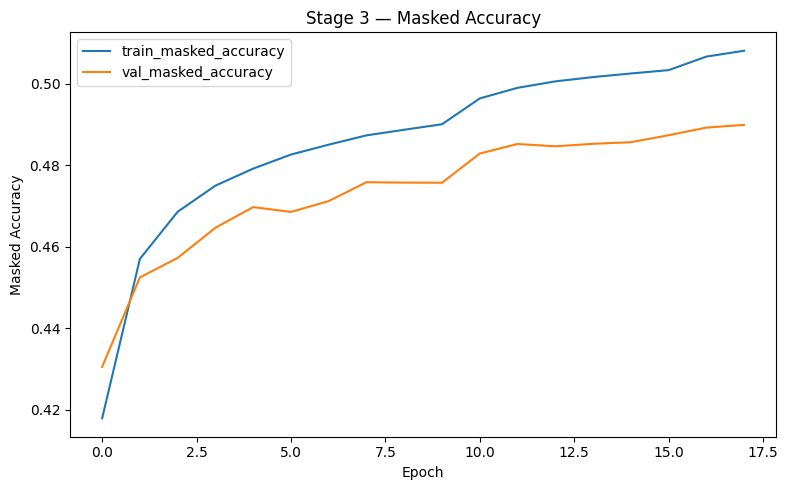

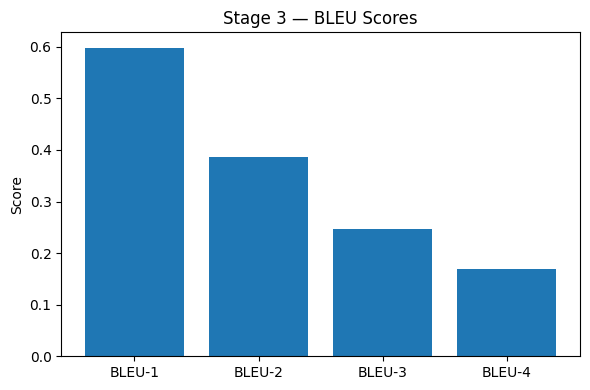

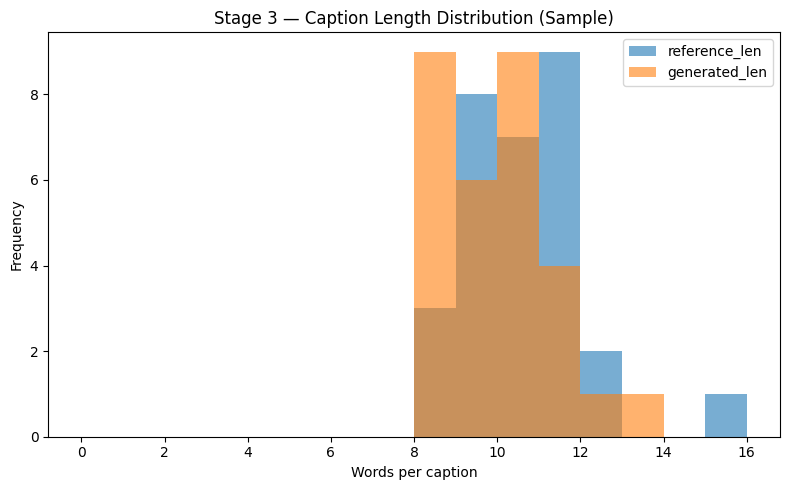

Charts saved in: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage3


In [12]:
# Cell Y — Stage 3 charts
import pandas as pd
import matplotlib.pyplot as plt

# history df
if "history" in globals():
    hist_df = pd.DataFrame(history.history)
else:
    hist_df = pd.read_csv(ART_DIR / "training_history.csv")

# 1) Loss curve
plt.figure(figsize=(8,5))
plt.plot(hist_df["loss"], label="train_loss")
plt.plot(hist_df["val_loss"], label="val_loss")
plt.title("Stage 3 — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(ART_DIR / "chart_loss_curve.png", dpi=180)
plt.show()

# 2) Accuracy curve (if available)
if "masked_accuracy" in hist_df.columns and "val_masked_accuracy" in hist_df.columns:
    plt.figure(figsize=(8,5))
    plt.plot(hist_df["masked_accuracy"], label="train_masked_accuracy")
    plt.plot(hist_df["val_masked_accuracy"], label="val_masked_accuracy")
    plt.title("Stage 3 — Masked Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Masked Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(ART_DIR / "chart_masked_accuracy_curve.png", dpi=180)
    plt.show()

# 3) BLEU bar chart
m = pd.read_csv(ART_DIR / "metrics_table.csv").set_index("metric")["value"].to_dict()
bleu_vals = [m.get("test_bleu1", 0), m.get("test_bleu2", 0), m.get("test_bleu3", 0), m.get("test_bleu4", 0)]
plt.figure(figsize=(6,4))
plt.bar(["BLEU-1","BLEU-2","BLEU-3","BLEU-4"], bleu_vals)
plt.title("Stage 3 — BLEU Scores")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig(ART_DIR / "chart_bleu_scores.png", dpi=180)
plt.show()

# 4) Caption length comparison (from sample file)
sample_path = ART_DIR / "sample_caption_predictions.csv"
if sample_path.exists():
    s = pd.read_csv(sample_path)
    if "generated_caption" in s.columns and "reference_caption_1" in s.columns:
        gen_len = s["generated_caption"].fillna("").str.split().str.len()
        ref_len = s["reference_caption_1"].fillna("").str.split().str.len()
        plt.figure(figsize=(8,5))
        bins = range(0, int(max(gen_len.max(), ref_len.max())) + 2)
        plt.hist(ref_len, bins=bins, alpha=0.6, label="reference_len")
        plt.hist(gen_len, bins=bins, alpha=0.6, label="generated_len")
        plt.title("Stage 3 — Caption Length Distribution (Sample)")
        plt.xlabel("Words per caption")
        plt.ylabel("Frequency")
        plt.legend()
        plt.tight_layout()
        plt.savefig(ART_DIR / "chart_caption_length_distribution.png", dpi=180)
        plt.show()

print("Charts saved in:", ART_DIR)


In [14]:
# Fallback save (no tabulate dependency)
qual_table.to_csv(ART_DIR / "qualitative_examples_top12.csv", index=False)
(ART_DIR / "qualitative_examples_top12.txt").write_text(
    qual_table.to_string(index=False),
    encoding="utf-8"
)
print("Saved CSV + TXT qualitative tables.")


Saved CSV + TXT qualitative tables.


In [15]:
%pip install -q tabulate

Note: you may need to restart the kernel to use updated packages.


In [16]:
# Stage 3 qualitative table for vlog/report (top 12 examples)
import pandas as pd
from IPython.display import display

sample_path = ART_DIR / "sample_caption_predictions.csv"
assert sample_path.exists(), f"Missing: {sample_path}"

s = pd.read_csv(sample_path).fillna("")

# Ensure expected columns exist
for c in ["image_name", "generated_caption", "reference_caption_1"]:
    if c not in s.columns:
        s[c] = ""

# Add quick diagnostics
s["gen_len"] = s["generated_caption"].str.split().str.len()
s["ref_len"] = s["reference_caption_1"].str.split().str.len()
s["len_gap"] = (s["gen_len"] - s["ref_len"]).abs()

# Pick a balanced set: lowest length-gap first (cleaner qualitative examples)
q = s.sort_values(["len_gap", "image_name"]).head(12).copy()

# Add short versions for slide readability
def short(txt, n=120):
    txt = str(txt).strip()
    return txt if len(txt) <= n else txt[:n-3] + "..."

q["generated_caption_short"] = q["generated_caption"].map(lambda x: short(x, 120))
q["reference_caption_short"] = q["reference_caption_1"].map(lambda x: short(x, 120))

cols = [
    "image_name",
    "generated_caption_short",
    "reference_caption_short",
    "gen_len",
    "ref_len",
    "len_gap",
]
qual_table = q[cols].reset_index(drop=True)

# Save full + slide-friendly
qual_table.to_csv(ART_DIR / "qualitative_examples_top12.csv", index=False)

# Markdown table for easy copy into report/vlog notes
md = qual_table.rename(columns={
    "generated_caption_short": "generated",
    "reference_caption_short": "reference"
}).to_markdown(index=False)
(ART_DIR / "qualitative_examples_top12.md").write_text(md, encoding="utf-8")

display(qual_table)
print("Saved:", ART_DIR / "qualitative_examples_top12.csv")
print("Saved:", ART_DIR / "qualitative_examples_top12.md")


,image_name,generated_caption_short,reference_caption_short,gen_len,ref_len,len_gap
0,000000289659.jpg,a giraffe standing in a field with trees in th...,a giraffe standing on top of a dirt and grass ...,11,11,0
1,000000290293.jpg,a large clock tower with a clock on its side,a long subway with people in it is lit up,10,10,0
2,000000290843.jpg,a cat is sitting on a bed with a stuffed animal,a woman sitting on a laptop computer next to a...,11,11,0
3,000000291791.jpg,a man is sitting on a bench with a laptop,a green motorcycle parked on top of a green lawn,10,10,0
4,000000292060.jpg,a kitchen with a stove and a refrigerator,a white kitchen with stove sink and refrigerator,8,8,0
5,000000289594.jpg,a man is walking down the street with a skateb...,a man in a hat leaning against a pole,10,9,1
6,000000289702.jpg,a man sitting on a couch with a laptop,large black dog sitting in front of a big mirror,9,10,1
7,000000289938.jpg,a large clock tower with a clock on its side,a hot dog cart across from the radio city musi...,10,11,1
8,000000289992.jpg,a white refrigerator freezer sitting inside of...,a plain white bathroom with a sink and a tub,9,10,1
9,000000290163.jpg,a woman sitting at a table with a plate of food,a little girl puts her hand in a pasta dish,11,10,1


Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage3/qualitative_examples_top12.csv
Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage3/qualitative_examples_top12.md


In [17]:
# Cell 10 — gate
required = [
    ART_DIR / "selected_split_sizes.json",
    ART_DIR / "training_history.csv",
    ART_DIR / "training_curve_loss.png",
    ART_DIR / "bleu_scores.png",
    ART_DIR / "sample_caption_predictions.csv",
    ART_DIR / "metrics.json",
    ART_DIR / "tokenizer.json",
    MODEL_DIR / "best_stage3_scratch.keras",
    MODEL_DIR / "cnn_lstm_scratch_final.keras",
]
for p in required:
    assert p.exists(), f"Missing: {p}"

m = json.loads((ART_DIR / "metrics.json").read_text(encoding="utf-8"))
assert not np.isnan(m["test_bleu1"]) and not np.isnan(m["test_bleu4"])

print("STAGE 3 PASS")
print("BLEU-1:", round(m["test_bleu1"], 4), "| BLEU-4:", round(m["test_bleu4"], 4))


STAGE 3 PASS
BLEU-1: 0.5981 | BLEU-4: 0.1685
